[https://osmnx.readthedocs.io/en/stable/user-reference.html](https://osmnx.readthedocs.io/en/stable/user-reference.html)

# Import aller Libaries

In [ ]:
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx
import math


print(f'OSMnx Verion: {ox.__version__}')
print(f'Networkx Verion: {nx.__version__}')

OSMnx Verion: 2.1.0
Networkx Verion: 3.6.1


# Strassennetz Vorbereiten

In [21]:
place = "Zürich, Schweiz"
G = ox.graph.graph_from_place(place, network_type="drive", simplify=True)

In [22]:
G_WebMerk = ox.projection.project_graph(G, to_crs=3857, to_latlong=False)

In [23]:
G_WebMerk_elev = ox.elevation.add_node_elevations_raster(G_WebMerk, 'DEM/dhm_webmercator.tif', band=1, cpus=None)
nodes, edges = ox.convert.graph_to_gdfs(G_WebMerk_elev)


In [ ]:
G_WebMerk_elev = ox.elevation.add_edge_grades(G_WebMerk_elev, add_absolute=True)
nodes, edges = ox.convert.graph_to_gdfs(G_WebMerk_elev)


In [ ]:
def euclidean_heuristic(u, v):
    dx = G.nodes[u]['x'] - G.nodes[v]['x']
    dy = G.nodes[u]['y'] - G.nodes[v]['y']
    return math.sqrt(dx**2 + dy**2)


In [ ]:
nx.astar_path(G, , s, heuristic=euclidean_heuristic, weight="cost")

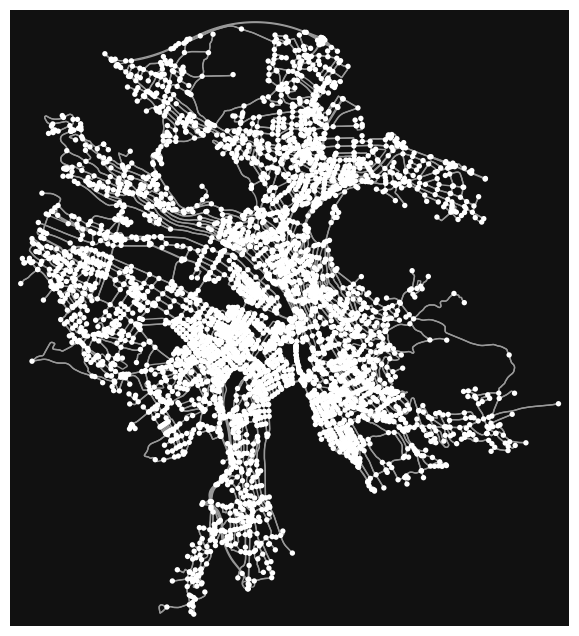

In [14]:
fig, ax = ox.plot.plot_graph(
    G_WebMerk,
    ax=None,  # optionally draw on pre-existing axis
    figsize=(8, 8),  # figure size to create if ax is None
    bgcolor="#111111",  # background color of the plot
    node_color="w",  # color of the nodes
    node_size=15,  # size of the nodes: if 0, skip plotting them
    node_alpha=None,  # opacity of the nodes
    node_edgecolor="none",  # color of the nodes' markers' borders
    node_zorder=1,  # zorder to plot nodes: edges are always 1
    edge_color="#999999",  # color of the edges
    edge_linewidth=1,  # width of the edges: if 0, skip plotting them
    edge_alpha=None,  # opacity of the edges
    show=True,  # if True, call pyplot.show() to show the figure
    close=False,  # if True, call pyplot.close() to close the figure
    save=False,  # if True, save figure to disk at filepath
    filepath=None,  # if save is True, the path to the file
    dpi=300,  # if save is True, the resolution of saved file
    bbox=None,  # bounding box to constrain plot
)

# Performance Test Bidirectional Dijkstra VS A Star

### Benchmark mit 1000 Punktpaaren

,algorithm,pairs,successes,failures,total_s,mean_ms,median_ms,min_ms,max_ms
0,Bidirectional Dijkstra,10000,10000,0,34.907,3.490,3.209,0.016,34.475
1,A*,10000,10000,0,20.444,2.044,1.540,0.012,16.873


Benchmark-Graph: 4584 Nodes, 10499 Edges
Heuristik-Skalierung fuer A*: 0.670
Speedup A* gegenueber Bidirectional Dijkstra: 1.71x
Maximale Differenz der Routenlaengen: 0.000000 m


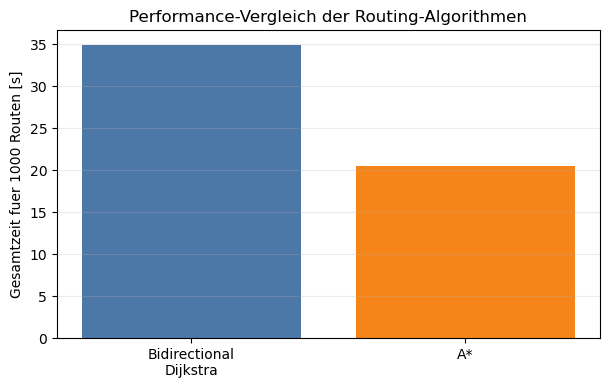

In [19]:
import math
import random
import time
from statistics import mean, median

BENCHMARK_PAIRS = 10000
RANDOM_SEED = 42
WEIGHT = "length"

# Fuer faire Vergleiche: beide Algorithmen laufen auf demselben Graphen.
G_benchmark_source = G_WebMerk_elev if "G_WebMerk_elev" in globals() else G_WebMerk

# Bei einem gerichteten Strassennetz vermeiden wir NoPath-Faelle, indem wir die
# groesste stark zusammenhaengende Komponente verwenden.
if G_benchmark_source.is_directed():
    largest_component = max(nx.strongly_connected_components(G_benchmark_source), key=len)
else:
    largest_component = max(nx.connected_components(G_benchmark_source), key=len)

G_benchmark = G_benchmark_source.subgraph(largest_component).copy()
benchmark_nodes = list(G_benchmark.nodes)

rng = random.Random(RANDOM_SEED)
node_pairs = [tuple(rng.sample(benchmark_nodes, 2)) for _ in range(BENCHMARK_PAIRS)]

WEB_MERCATOR_RADIUS = 6378137.0

def webmercator_y_to_lat(y):
    return math.degrees(2 * math.atan(math.exp(y / WEB_MERCATOR_RADIUS)) - math.pi / 2)

# Web Mercator uebertreibt Distanzen. Dieser Faktor macht die Luftlinien-
# Heuristik konservativ, passend zur Kantenlaenge in Metern.
latitudes = [webmercator_y_to_lat(data["y"]) for _, data in G_benchmark.nodes(data=True)]
heuristic_scale = min(math.cos(math.radians(abs(lat))) for lat in latitudes) * 0.99

def astar_heuristic(u, v):
    ux, uy = G_benchmark.nodes[u]["x"], G_benchmark.nodes[u]["y"]
    vx, vy = G_benchmark.nodes[v]["x"], G_benchmark.nodes[v]["y"]
    return math.hypot(ux - vx, uy - vy) * heuristic_scale

def benchmark(name, route_length_func):
    durations = []
    lengths = []
    failures = 0

    start_total = time.perf_counter()
    for source, target in node_pairs:
        start = time.perf_counter()
        try:
            lengths.append(route_length_func(source, target))
            durations.append(time.perf_counter() - start)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            failures += 1

    total = time.perf_counter() - start_total
    return {
        "algorithm": name,
        "pairs": len(node_pairs),
        "successes": len(durations),
        "failures": failures,
        "total_s": total,
        "mean_ms": mean(durations) * 1000,
        "median_ms": median(durations) * 1000,
        "min_ms": min(durations) * 1000,
        "max_ms": max(durations) * 1000,
        "lengths": lengths,
        "durations": durations,
    }

dijkstra_result = benchmark(
    "Bidirectional Dijkstra",
    lambda source, target: nx.bidirectional_dijkstra(
        G_benchmark,
        source,
        target,
        weight=WEIGHT,
    )[0],
)

astar_result = benchmark(
    "A*",
    lambda source, target: nx.astar_path_length(
        G_benchmark,
        source,
        target,
        heuristic=astar_heuristic,
        weight=WEIGHT,
    ),
)

summary = []
for result in [dijkstra_result, astar_result]:
    summary.append({
        "algorithm": result["algorithm"],
        "pairs": result["pairs"],
        "successes": result["successes"],
        "failures": result["failures"],
        "total_s": round(result["total_s"], 3),
        "mean_ms": round(result["mean_ms"], 3),
        "median_ms": round(result["median_ms"], 3),
        "min_ms": round(result["min_ms"], 3),
        "max_ms": round(result["max_ms"], 3),
    })

speedup = dijkstra_result["total_s"] / astar_result["total_s"]
max_length_delta = max(
    abs(dijkstra_length - astar_length)
    for dijkstra_length, astar_length in zip(dijkstra_result["lengths"], astar_result["lengths"])
)

try:
    import pandas as pd

    summary_df = pd.DataFrame(summary)
    display(summary_df)
except ImportError:
    for row in summary:
        print(row)

print(f"Benchmark-Graph: {G_benchmark.number_of_nodes()} Nodes, {G_benchmark.number_of_edges()} Edges")
print(f"Heuristik-Skalierung fuer A*: {heuristic_scale:.3f}")
print(f"Speedup A* gegenueber Bidirectional Dijkstra: {speedup:.2f}x")
print(f"Maximale Differenz der Routenlaengen: {max_length_delta:.6f} m")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    ["Bidirectional\nDijkstra", "A*"],
    [dijkstra_result["total_s"], astar_result["total_s"]],
    color=["#4c78a8", "#f58518"],
)
ax.set_ylabel("Gesamtzeit fuer 1000 Routen [s]")
ax.set_title("Performance-Vergleich der Routing-Algorithmen")
ax.grid(axis="y", alpha=0.25)
plt.show()
